# From CDS spreads to a par spread

This notebook runs the credit module of my pricer (`src/pricer/credit/cds.py`) on one example and follows the chain below. To try other numbers, change the inputs in the second cell and run everything again.

```
CDS spreads  ->  hazard curve  ->  survival probability Q(t)  ->  premium leg + protection leg  ->  par spread, value, upfront
```

Times are in years and the discount rate is flat. Payments are quarterly, made at the end of each period. A default is assumed to happen in the middle of a period. Recovery is constant.

In [47]:
import numpy as np
import matplotlib.pyplot as plt

from pricer.credit.cds import (
    bootstrap_hazard_curve, survival_probability, risky_annuity, protection_leg,
    par_spread, value_to_protection_buyer, upfront,
)

plt.rcParams["figure.figsize"] = (7, 3)

In [48]:
maturities = [1, 3, 5]            # quoted CDS maturities, in years
spreads = [0.008, 0.012, 0.015]   # their spreads: 80bp, 120bp, 150bp
rate = 0.03                       # flat interest rate
recovery = 0.4
notional = 10_000_000             # EUR

## 1. Market spreads to hazard curve

A CDS spread is a price. To use it for other maturities or other products, I convert it into a hazard rate $\lambda$: the probability per year that the company defaults, given that it has survived until now.

I assume $\lambda$ is constant between two quoted maturities and solve one maturity at a time, shortest first. At step $k$ the rates $\lambda_1,\dots,\lambda_{k-1}$ are already known, so only $\lambda_k$ is unknown:

$$\text{par spread}(T_k;\ \lambda_1,\dots,\lambda_k) = s_k$$

`brentq` finds the $\lambda_k$ for which the model spread equals the quoted spread $s_k$. As a rough check, the credit triangle says $s \approx \lambda\,(1-R)$.

hazard rates (%): [1.328 2.35  3.352]


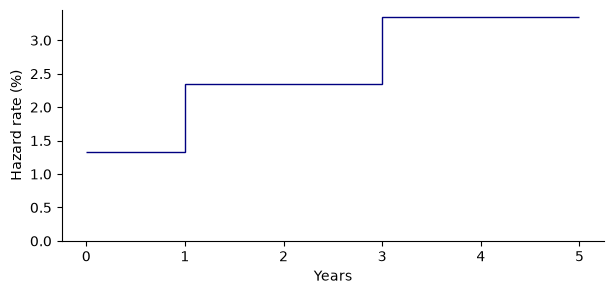

In [49]:
curve = bootstrap_hazard_curve(maturities, spreads, rate, recovery)
curve_times, hazard_rates = curve
print("hazard rates (%):", np.round(hazard_rates * 100, 3))

plt.stairs(hazard_rates * 100, [0] + list(curve_times), baseline=None, color="navy")   # one step per bucket
plt.ylim(bottom=0)
plt.xlabel("Years")
plt.ylabel("Hazard rate (%)")
plt.show()

Each step is the hazard rate of one bucket: 0 to 1 year, 1 to 3 years, 3 to 5 years. The spreads rise with maturity, so the steps rise: the market sees little risk next year and more later. Repricing each quoted CDS with this curve should give back the quotes:

In [50]:
for maturity in maturities:
    print(maturity, "Y repriced spread (bp):", round(par_spread(maturity, curve, rate, recovery) * 10000, 2))

1 Y repriced spread (bp): 80.0
3 Y repriced spread (bp): 120.0
5 Y repriced spread (bp): 150.0


## 2. Hazard curve to survival probability

Surviving to time $t$ means surviving every bucket before it. Probabilities of consecutive events multiply, so the hazard rates add up in the exponent:

$$Q(t) = \exp\bigl(-H(t)\bigr), \qquad H(t) = \sum_k \lambda_k \times (\text{time spent in bucket } k)$$

The probability of defaulting during one period is the drop in survival, $Q(t_{i-1}) - Q(t_i)$. It feeds both the protection leg and the accrued premium.

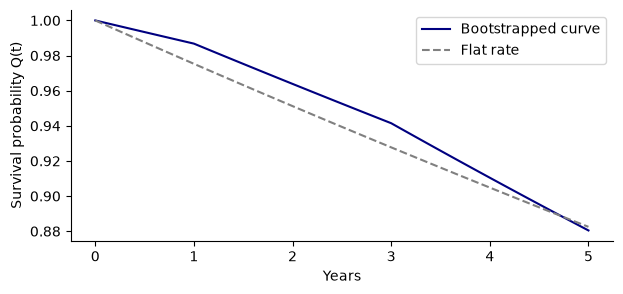

In [51]:
years = np.linspace(0, 5, 101)
flat_rate = spreads[-1] / (1 - recovery)    # credit triangle with the 5Y spread

plt.plot(years, survival_probability(years, curve), color="navy", label="Bootstrapped curve")
plt.plot(years, survival_probability(years, flat_rate), color="grey", linestyle="--", label="Flat rate")
plt.xlabel("Years")
plt.ylabel("Survival probability Q(t)")
plt.legend()
plt.show()

The flat line uses one hazard rate for the whole life, taken from the 5Y spread. It misprices the short maturities because the market quotes a lower spread for 1 year than for 5 years.

## 3. Survival probability to the two legs

For a CDS with payment dates $t_1,\dots,t_n$, year fractions $\Delta_i = t_i - t_{i-1}$, and default assumed in the middle of each period, $m_i = t_i - \Delta_i/2$:

$$\text{RPV01} = \sum_i \Delta_i\,D(t_i)\,Q(t_i) \;+\; \sum_i \tfrac{\Delta_i}{2}\,D(m_i)\,\bigl(Q(t_{i-1})-Q(t_i)\bigr)$$

The first sum is the premiums paid while the company is alive. The second is the accrued premium owed if it defaults during a period.

$$PV_{\text{protection}} = (1-R)\sum_i D(m_i)\,\bigl(Q(t_{i-1})-Q(t_i)\bigr)$$

The premium leg is $s \times \text{RPV01}$.

RPV01: 4.3946
Protection leg (% of notional): 6.592
Par spread (bp): 150.0


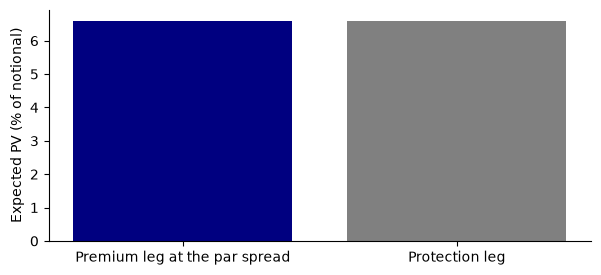

In [52]:
annuity = risky_annuity(5, curve, rate)  # RPV01 of the 5Y CDS
protection = protection_leg(5, curve, rate, recovery)
fair_spread = protection / annuity

print("RPV01:", round(annuity, 4))
print("Protection leg (% of notional):", round(protection * 100, 3))
print("Par spread (bp):", round(fair_spread * 10000, 2))

plt.bar(["Premium leg at the par spread", "Protection leg"], [fair_spread * annuity * 100, protection * 100], color=["navy", "grey"])
plt.ylabel("Expected PV (% of notional)")
plt.show()

At the par spread the two legs have the same value, so the two bars are equal. This is the definition of the par spread.

## 4. Legs to par spread, value and upfront

$$s^* = \frac{PV_{\text{protection}}}{\text{RPV01}}$$

$V(s)$ is the value of the CDS to the protection buyer when the contract pays the spread $s$:

$$V(s) = PV_{\text{protection}} - s\cdot\text{RPV01} = (s^* - s)\,\text{RPV01}$$

- At $s = s^*$ the CDS is worth zero: nobody pays anything at inception.
- If the contract pays more than $s^*$, the buyer overpays and $V$ is negative.
- With a standard coupon $c$ (100bp or 500bp), the gap to the fair spread is settled with an upfront payment, $\text{Upfront}(c) = (s^*-c)\,\text{RPV01}$. A positive upfront is paid by the buyer.
- If the market spread $s^*$ rises by one basis point, an existing contract gains about $\text{RPV01} \times \text{notional} \times 0.0001$. That is the CS01.

Value to the buyer of a 200bp contract (EUR): -219732
Upfront at a 100bp coupon (EUR, positive = buyer pays): 219732
CS01 (EUR per bp): 4395


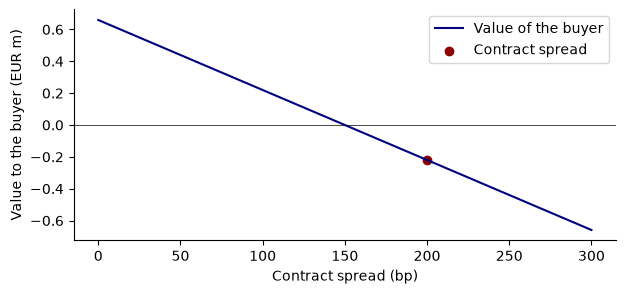

In [53]:
s_contract = 0.02               # contract paying 200bp
value = value_to_protection_buyer(s_contract, 5, curve, rate, recovery)    
print("Value to the buyer of a 200bp contract (EUR):", round(value * notional))

up = upfront(0.01, 5, curve, rate, recovery)       # standard coupon of 100bp
print("Upfront at a 100bp coupon (EUR, positive = buyer pays):", round(up * notional))
print("CS01 (EUR per bp):", round(annuity * notional * 0.0001))

spread_grid = np.linspace(0, 0.03, 31)
values = []
for s in spread_grid:
    values.append(value_to_protection_buyer(s, 5, curve, rate, recovery) * notional / 1e6)

plt.plot(spread_grid * 10000, values, color="navy", label="Value of the buyer")
plt.axhline(0, color="black", linewidth=0.5)
plt.scatter([s_contract*10000], [value * notional / 1e6], color="darkred", label="Contract spread")        # the 200bp contract
plt.xlabel("Contract spread (bp)")
plt.ylabel("Value to the buyer (EUR m)")
plt.legend()
plt.show()

The value to the buyer is a straight line that falls by RPV01 for each unit of contract spread, and it crosses zero at the par spread. The red dot is the 200bp contract: it is above the 150bp par spread, so the buyer overpays and the value is negative.

## 5. Checks

Two checks on the pricer. The credit triangle gives the par spread of a CDS that pays continuously. With discrete payments the exact spread is a little higher and converges to the triangle value as payments become more frequent.

In [54]:
hazard = 0.02
triangle = hazard * (1 - 0.4) * 10000    # credit triangle in bp: 120

# Check 1: textbook example, annual payments
example = par_spread(5, hazard, 0.05, 0.4, frequency=1) * 10000
print("Example (hazard 2%, r 5%, R 40%, annual payments):", round(example, 1), "bp, published value 123bp")

# Check 2: the more often we pay, the closer we get to the credit triangle
for payments in [1, 4, 12]:
    spread = par_spread(5, hazard, 0.05, 0.4, frequency=payments) * 10000
    print(payments, "payments a year:", round(spread, 2), "bp (credit triangle:", round(triangle, 1), "bp)")

Example (hazard 2%, r 5%, R 40%, annual payments): 123.0 bp, published value 123bp
1 payments a year: 123.0 bp (credit triangle: 120.0 bp)
4 payments a year: 120.75 bp (credit triangle: 120.0 bp)
12 payments a year: 120.25 bp (credit triangle: 120.0 bp)


## What this model simplifies

- One flat discount rate; the market discounts on an OIS curve.
- A default is assumed in the middle of the period; the exact model integrates over the default date.
- Constant recovery (40% by convention for senior unsecured debt).
- No day-count conventions (CDS use ACT/360) and no IMM dates.
- Hazard rates are constant between quoted maturities.
- The quoted spreads are treated as par spreads. The market quotes standard coupons and upfronts.

## My interview sheet

### The chain

CDS spreads give a hazard curve, the hazard curve gives survival probabilities, and survival probabilities give the marginal default probabilities. The same survival curve prices the premium leg and the protection leg, and the par spread is their ratio.

### Formulas

$$Q(t) = e^{-H(t)} \qquad \text{RPV01} = \sum_i \Delta_i D(t_i) Q(t_i) + \text{accrued} \qquad PV_{\text{prot}} = (1-R)\sum_i D(m_i)\bigl(Q(t_{i-1})-Q(t_i)\bigr)$$

$$s^* = \frac{PV_{\text{prot}}}{\text{RPV01}} \qquad V(s) = PV_{\text{protection}} - s\cdot\text{RPV01} = (s^*-s)\,\text{RPV01} \qquad \text{Upfront} = (s^*-c)\,\text{RPV01} \qquad \text{CS01} \approx \text{RPV01}\times N\times 0.0001$$

### My 30-second definition

A CDS has a premium leg and a protection leg. I value both with a survival curve. To get the curve, I bootstrap a piecewise-constant hazard rate from the quoted spreads, shortest maturity first: at each step one hazard rate is unknown and a root finder makes the model spread match the quote. With the curve, the premium leg is the spread times the risky annuity and the protection leg is the loss given default times the discounted default probabilities. The par spread is their ratio, and the value of an existing contract is the protection leg minus the premium it pays.

### My personal note : Interview questions

How do you get default probabilities from CDS spreads? Why is a CDS worth zero at inception? What is the upfront and who pays it? What is the RPV01? What does the credit triangle assume? How do you check a calibration?